# Optimal Portfolio Construction Based on Modern Portfolio Theory: Outperforming the Benchmark Index

---

# Objective:

- To apply Modern Portfolio Theory (MPT) for constructing optimal portfolios using historical stock data from BSE Sensex constituents.
- To use Monte Carlo simulation for generating a wide range of portfolio combinations and identifying those with superior return-risk profiles.
- To maximize risk-adjusted returns (Sharpe ratio) and assess performance relative to the benchmark index (Sensex).
- To implement a rolling window backtesting framework (2-year training, 1-year testing) for evaluating the robustness and consistency of portfolio performance over time.
- To demonstrate that data-driven, systematic portfolio construction can outperform the benchmark over an extended investment horizon.


---

# Methodology:

- Data collection:
  - Collected daily adjusted closing prices (2012–2025) for the BSE Sensex and its 30 constituent stocks from Yahoo Finance.

- Rolling Framework:
  - Implemented a 2-year training and 1-year testing rolling window, covering approximately a 10-year period.

- Monte Carlo Portfolio Simulation:
  - For each training window, generated 100,000 random portfolios (no short positions), each consisting of 10 randomly selected Sensex stocks.
  - Calculated annualized returns, volatility, and Sharpe ratios for each portfolio.
  - Selected the portfolio with the highest Sharpe ratio as the optimal one.

- Backtesting:
  - Applied optimal portfolio weights to the corresponding one year test period.
  - Evaluated performance using cumulative return, volatility, and Sharpe ratio.

- Visualization:
  - Plotted yearly returns, volatility, and Sharpe ratio comparisons between the optimal portfolio and the Sensex across the full test period.
  - For the 2022–2023 training window: Plotted the Efficient Frontier with the optimal portfolio marked and drew the Capital Market Line (CML).
  - For the corresponding test period (2025), plotted cumulative return comparison between the optimal portfolio and the Sensex


---

# Key Findings:

- Outperformance: The optimized 10-stock portfolios consistently outperformed the Sensex in most test years, both in terms of cumulative return and Sharpe ratio.

- Sharpe Optimal Portfolios: Portfolios maximizing the Sharpe ratio often had significantly better risk-adjusted returns than both minimum variance portfolios and the Sensex.

- Efficient Frontiers: Each training window produced a distinct efficient frontier, highlighting shifting return-risk tradeoffs across time.

- Consistency: Despite changing market conditions, the Monte Carlo simulation method reliably identified strong portfolio candidates over multiple rolling windows.


---

# Conclusion:

- Effectiveness of Monte Carlo Optimization: Simulating a large number of portfolios is a practical way to explore the efficient frontier and identify high-performing portfolios without needing advanced optimization tools.

- Data-Driven Decision Making: Historical returns and volatilities, when used with proper rolling windows, can provide meaningful guidance for portfolio construction.

---



# Code and analysis

Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
np.random.seed(500)

I used the SENSEX index data, consisting of the top 30 companies listed on the BSE, along with their respective weights as of October 2024.

In [2]:
sensex_stocks = pd.read_csv("Sensex_data.csv")
sensex_stocks.head()


,Company Name,Stock Symbol (NSE),Weightage (%)
0,Adani Ports & Special Economic Zone Ltd,ADANIPORTS,1.09
1,Asian Paints Ltd.,ASIANPAINT,1.54
2,Axis Bank Ltd.,AXISBANK,3.61
3,Bajaj Finserv Ltd.,BAJAJFINSV,1.10
4,Bajaj Finance Ltd.,BAJFINANCE,2.21


We will use two years of stock return data as the training dataset to construct the efficient frontier and identify the optimal portfolio based on the Sharpe ratio. The following one year of data will be used for backtesting the performance of the optimal portfolio against the SENSEX index portfolio.

In [3]:

start_date = "2012-01-01"
end_date = "2025-01-02" 


ticker_set = [symbol + ".NS" for symbol in sensex_stocks["Stock Symbol (NSE)"]]

data = yf.download(ticker_set, start=start_date, end=end_date)['Close']
sensex_data = yf.download("^BSESN", start=start_date, end=end_date)['Close']


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  30 of 30 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
data = data.sort_index()
data = data.pct_change().dropna()
sensex_data = sensex_data.pct_change().dropna()

In [5]:
num_assets = 30
risk_free_rate = 0.06
desired_portfolio_size = 10

In [6]:
metric = []

train_years = 2
test_years = 1

start = pd.Timestamp(start_date)

while True:
    train_start = start
    train_end = train_start + pd.DateOffset(years=train_years)
    test_end = train_end + pd.DateOffset(years=test_years)


    if test_end > data.index.max():
        break

    train_data = data[(data.index >= train_start) & (data.index < train_end)]
    test_data = data[(data.index >= train_end) & (data.index < test_end)]

    returns = train_data.mean() * 252
    cov_matrix = train_data.cov() * 252
    
    num_sim_portfolios = 10**5
    
    all_weights = np.zeros((num_sim_portfolios, num_assets))
    
    ret_arr = np.zeros(num_sim_portfolios)
    vol_arr = np.zeros(num_sim_portfolios)
    sharpe_arr = np.zeros(num_sim_portfolios)

    for i in range(num_sim_portfolios):
        weights = np.zeros(num_assets)
        non_zero_indices = np.random.choice(30, 10, replace=False)
        weights[non_zero_indices] = np.random.random(desired_portfolio_size)
        weights = weights / np.sum(weights) 
        portfolio_return = np.dot(weights, returns)
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_std = np.sqrt(portfolio_variance)
    
        all_weights[i, :] = weights
        ret_arr[i] = portfolio_return
        vol_arr[i] = portfolio_std
        sharpe_arr[i] = (portfolio_return - risk_free_rate) / portfolio_std

    max_sharpe_idx = np.argmax(sharpe_arr)
    optimal_weights = all_weights[max_sharpe_idx, :]

    optimal_portfolio_returns = (test_data * optimal_weights).sum(axis=1)

    sensex_test = sensex_data[(sensex_data.index >= train_end) & (sensex_data.index < test_end)]

    annualized_portfolio_return = optimal_portfolio_returns.mean() * 252
    annualized_portfolio_volatility = optimal_portfolio_returns.std() * np.sqrt(252)
    sharpe_ratio_portfolio = (annualized_portfolio_return-risk_free_rate) / annualized_portfolio_volatility

    annualized_sensex_return = np.mean(sensex_test) *252
    annualized_sensex_volatility = np.array(sensex_test).std() * np.sqrt(252)
    sharpe_ratio_sensex = (annualized_sensex_return - risk_free_rate) / annualized_sensex_volatility

    metric.append([train_end.year, round(annualized_portfolio_return *100, 2), round(annualized_sensex_return *100, 2) , 
                   round(annualized_portfolio_volatility *100, 2), round(annualized_sensex_volatility *100, 2),
                   round(sharpe_ratio_portfolio, 2), round(sharpe_ratio_sensex, 2)])

    start = start + pd.DateOffset(years=1)



The following data demonstrate that the portfolio consistently outperformed the Sensex index in terms of return, volatility, and Sharpe ratio in nearly every test year from 2014 to 2024.

In [7]:
df = pd.DataFrame(metric)

df.set_index(0, inplace=True)

df.columns = ['Portfolio return', 'Sensex return', "Portfolio volatility", "Sensex volatility", "Portfolio Sharpe", "Sensex Sharpe"]
df.index.name = 'Test year'
df

,Portfolio return,Sensex return,Portfolio volatility,Sensex volatility,Portfolio Sharpe,Sensex Sharpe
Test year,,,,,,
2014,38.74,28.28,13.59,12.67,2.41,1.76
2015,14.44,-3.98,16.36,16.24,0.52,-0.61
2016,15.45,3.09,18.51,14.88,0.51,-0.20
2017,48.66,25.42,14.87,8.91,2.87,2.18
2018,14.53,6.67,16.08,12.56,0.53,0.05
2019,22.85,15.00,15.18,13.87,1.11,0.65
2020,34.47,20.03,30.51,32.00,0.93,0.44
2021,31.38,21.54,15.25,15.84,1.66,0.98
2022,-3.85,5.94,19.85,17.45,-0.50,-0.00


Generated plots of the above data to enhance interpretability and facilitate comparison.

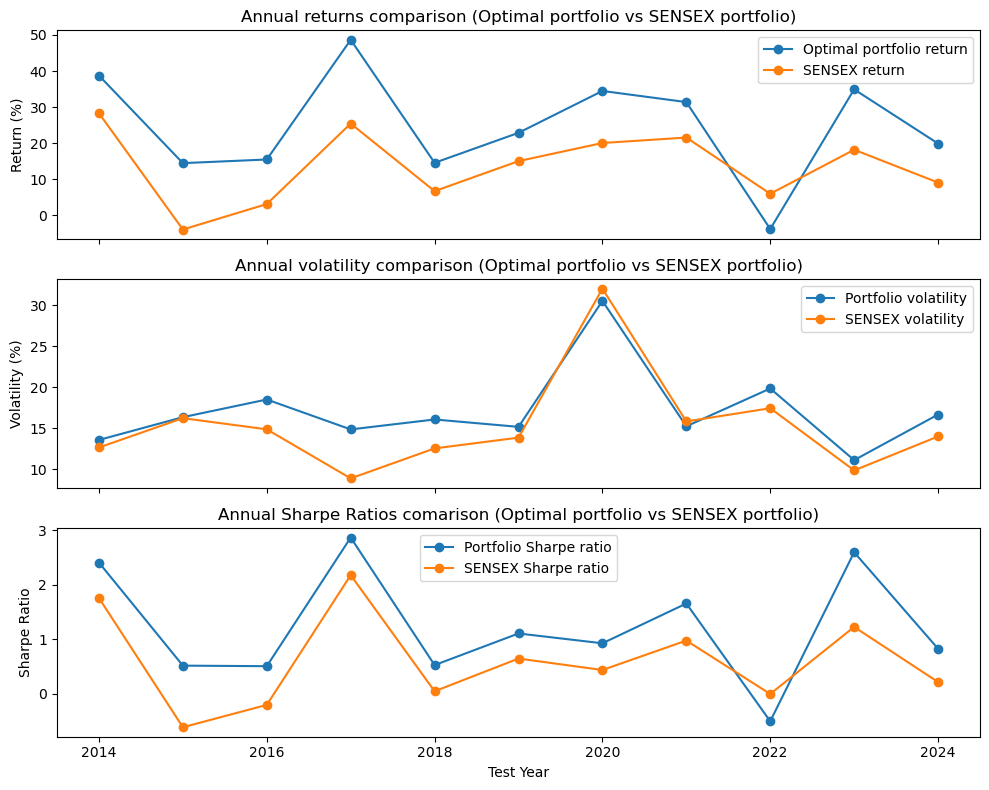

In [8]:

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)


axs[0].plot(df.index, df['Portfolio return'], label="Optimal portfolio return", marker='o')
axs[0].plot(df.index, df['Sensex return'], label="SENSEX return", marker='o')
axs[0].set_ylabel("Return (%)")
axs[0].set_title("Annual returns comparison (Optimal portfolio vs SENSEX portfolio)")
axs[0].legend()


axs[1].plot(df.index, df['Portfolio volatility'], label="Portfolio volatility", marker='o')
axs[1].plot(df.index, df['Sensex volatility'], label="SENSEX volatility", marker='o')
axs[1].set_ylabel("Volatility (%)")
axs[1].set_title("Annual volatility comparison (Optimal portfolio vs SENSEX portfolio)")
axs[1].legend()


axs[2].plot(df.index, df['Portfolio Sharpe'], label="Portfolio Sharpe ratio", marker='o')
axs[2].plot(df.index, df['Sensex Sharpe'], label="SENSEX Sharpe ratio", marker='o')
axs[2].set_ylabel("Sharpe Ratio")
axs[2].set_title("Annual Sharpe Ratios comarison (Optimal portfolio vs SENSEX portfolio)")
axs[2].legend()

plt.xlabel("Test Year")
plt.tight_layout()
plt.show()

Plot the Efficient Frontier using the portfolio data for the years 2022 and 2023.

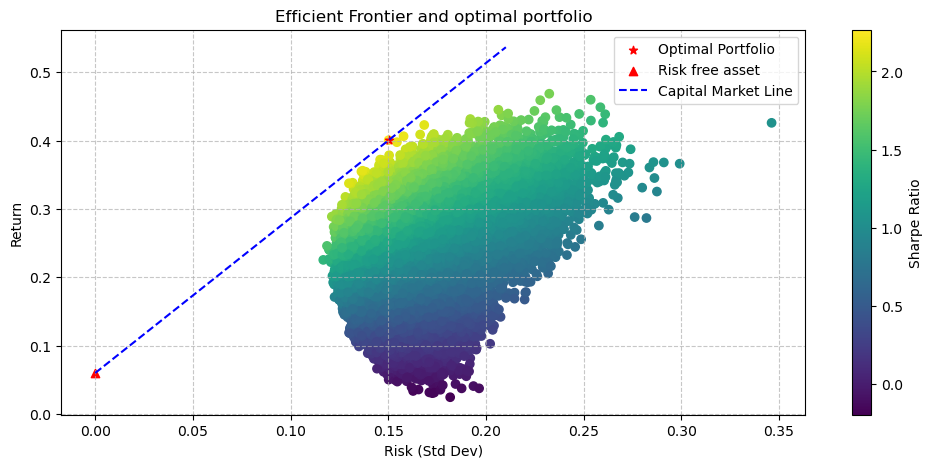

In [9]:
x1=0
x2=vol_arr[max_sharpe_idx]
y1=risk_free_rate
y2=ret_arr[max_sharpe_idx]
m=(y2-y1)/(x2-x1)
b = y1 - m * x1 
xval= np.linspace(x1,x2+0.06)
yval= m* xval + b 

plt.figure(figsize=(12, 5))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(vol_arr[max_sharpe_idx], ret_arr[max_sharpe_idx], c='red', marker='*', label='Optimal Portfolio')
plt.scatter(0, risk_free_rate, c='red', marker='^', label='Risk free asset')
plt.plot(xval, yval, 'b--', label='Capital Market Line')
plt.xlabel('Risk (Std Dev)')
plt.ylabel('Return')
plt.title('Efficient Frontier and optimal portfolio')
plt.grid(linestyle='--', alpha=0.7)
plt.legend()
plt.show()


Optimal Portfolio Allocation (based on the data of two years 2022 and 2023)

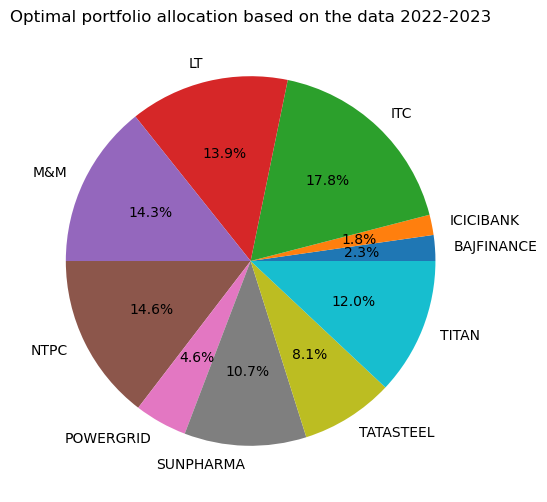

In [10]:
optimal_portfolio_allocation = optimal_weights[optimal_weights>0] *100
optimal_portfolio_stocks = sensex_stocks["Stock Symbol (NSE)"][optimal_weights>0]
plt.figure(figsize=(6,6))
plt.pie(optimal_portfolio_allocation, labels= optimal_portfolio_stocks, autopct='%1.1f%%')
plt.title('Optimal portfolio allocation based on the data 2022-2023')
plt.show()

Cumulative returns

In [11]:
optimal_portfolio_returns = (test_data * optimal_weights).sum(axis=1)
optimal_cum_returns = (1+ optimal_portfolio_returns).cumprod()-1
sensex_cum_returns = (1+sensex_test).cumprod()-1

Plot Backtest Performance (for the year 2024)

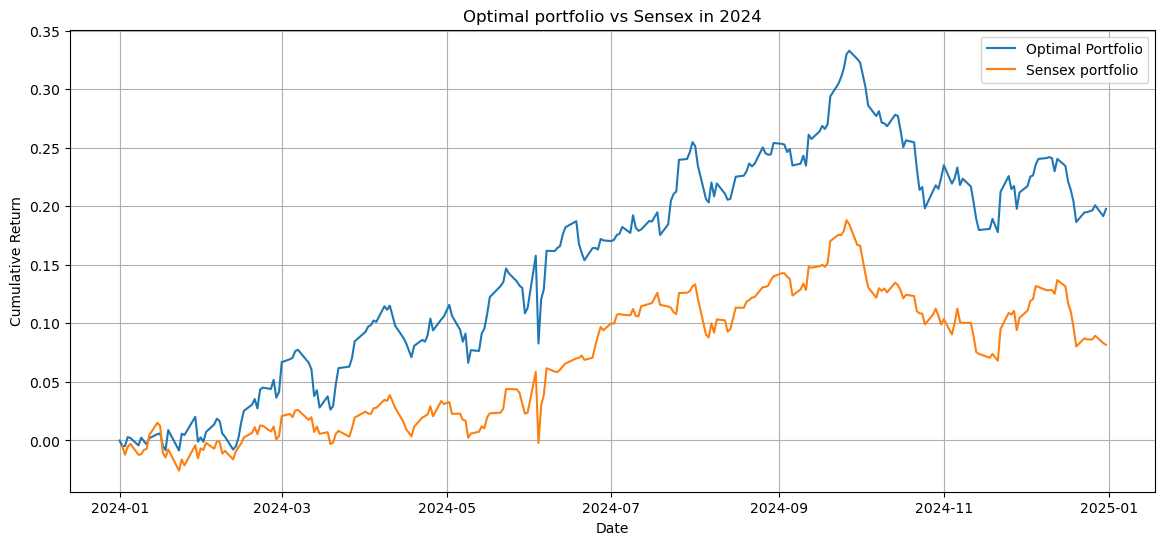

In [12]:
plt.figure(figsize=(14,6))
plt.plot(optimal_cum_returns, label="Optimal Portfolio")
plt.plot(sensex_cum_returns, label="Sensex portfolio")

plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Optimal portfolio vs Sensex in 2024')
plt.legend()
plt.grid(True)
plt.savefig("efficient_portfolio.png")
plt.show()